## 1. Physics-Informed Neural Network (PINN) 
Another possible way to solve the Black-Scholes model is through the use of machine learning. Partial Differential Equations (PDEs) are generally hard to solve and usually require numerical methods which can be computationally expensive. One approach currently being explored is a deep learning architecture known as a Physics-Informed Neural Network (PINN). This model is used to approximate the solutions to PDEs directly without a traditional mesh.

Given a general differential equation:

$$f(\vec{x}, t) = \frac{\partial u}{\partial t} + \mathcal{D}[u(\vec{x}, t)] = 0, \quad \vec{x} \in \Omega, \quad t \in [0, T]$$
 
where $\mathcal{D}$ is a non-linear differential operator. A neural network $\hat{u}(\vec{x},t; \theta)$ is trained to approximate the target function $u(\vec{x},t)$. The partial derivatives of $\hat{u}$ are calculated exactly using **Automatic Differentiation (AD)**. The total loss function for training the PINN is defined as:

$$MSE = MSE_u + MSE_f$$

$$MSE_u = \frac{1}{N_u} \sum_{i=1}^{N_u} \left| \hat{u}(\vec{x}_i^{(u)}, t_i^{(u)}; \theta) - u_i^{(u)} \right|^2$$

$$MSE_f = \frac{1}{N_f} \sum_{j=1}^{N_f} \left| f(\vec{x}_j^{(f)}, t_j^{(f)}; \theta) \right|^2$$

Where:
* $\hat{u}(\cdot; \theta)$ is the functional output of the neural network parameterized by weights and biases $\theta$.
* $(\vec{x}_i^{(u)}, t_i^{(u)})$ represent coordinates evaluated on the initial, terminal, or boundary constraints.
* $u_i^{(u)}$ represents the true specified value or target constraint at that point (e.g., terminal payoff).
* $f(\vec{x}_j^{(f)}, t_j^{(f)}; \theta)$ represents the residual evaluated at interior **collocation points**.

---

### References
* **Raissi et al. (2019):** *Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving partial differential equations.* [Journal of Computational Physics](https://www.sciencedirect.com/science/article/abs/pii/S0021999118307125)
* **Louskos (2021):** *Physics-Informed Neural Networks for Pricing Financial Options.* [Dartmouth College Thesis](https://math.dartmouth.edu/theses/undergrad/2021/Louskos-thesis.pdf)
* **Makarov (2023):** *Applications of Physics-Informed Neural Networks in Financial Engineering.* [arXiv:2312.06711](https://arxiv.org/abs/2312.06711)


The model will be built using **PyTorch** and optimized using the built-in **Adam optimizer**.

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
torch.cuda.init()

In [5]:
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility
K = 100        # Strike price
T = 1          # Time to maturity (1 year)
S_max = 3 * K  # Upper Boundary for S -> inf

In [6]:
# PINN model
# In features is S, t
class PINN_BS(nn.Module):

    def __init__(self, in_features = 2, out_features = 1, layers=3, hidden_layer=64):
        super().__init__()

        layer = [nn.Linear(in_features, hidden_layer), nn.Tanh()]
        for _ in range(layers):
            layer.append(nn.Linear(hidden_layer, hidden_layer))
            layer.append(nn.Tanh())
        layer.append(nn.Linear(hidden_layer, out_features))
        
        self.stack = nn.Sequential(*layer)
    
    def forward(self, x):
        return self.stack(x)

#### 1.1 Data and Boundary Loss ($MSE_u$)
The term $MSE_u$ enforces the boundary conditions ($S = 0$ and $S = S_{\max}$) as well as the terminal payoff condition ($t = T$). It is calculated as:

$$MSE_u = MSE_{bc1} + MSE_{bc2} + MSE_{term}$$

Where each component represents an average over its respective sampled boundary points:

* **Lower Boundary ($S = 0$):**
  $$MSE_{bc1} = \frac{1}{N_{b}} \sum_{i=1}^{N_{b}} \left| \hat{C}(0, t_i^{(b)}; \theta) - 0 \right|^2$$

* **Upper Boundary ($S = S_{\max}$):**
  $$MSE_{bc2} = \frac{1}{N_{b}} \sum_{i=1}^{N_{b}} \left| \hat{C}(S_{\max}, t_i^{(b)}; \theta) - \left( S_{\max} - K e^{-r(T - t_i^{(b)})} \right) \right|^2$$

* **Terminal Condition ($t = T$):**
  $$MSE_{term} = \frac{1}{N_{term}} \sum_{i=1}^{N_{term}} \left| \hat{C}(S_i^{(term)}, T; \theta) - \max(S_i^{(term)} - K, 0) \right|^2$$

Here, $\hat{C}$ denotes the option price predicted by the neural network, $N_{b}$ is the number of boundary evaluation points, and $N_{term}$ is the number of terminal samples.

---

#### 1.2 Residual Loss ($MSE_f$)
The term $MSE_f$ evaluates how well the network honors the underlying Black-Scholes PDE across $N_f$ collocation points randomly sampled from the interior domain $(S, t) \in (0, S_{\max}) \times (0, T)$. 

We define the interior physics residual $f(S, t)$ using automatic differentiation:

$$f(S, t) := \frac{\partial \hat{C}}{\partial t} + r S \frac{\partial \hat{C}}{\partial S} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 \hat{C}}{\partial S^2} - r\hat{C}$$

The interior loss is the mean squared residual across all interior points:

$$MSE_f = \frac{1}{N_f} \sum_{j=1}^{N_f} \left| f(S_j^{(f)}, t_j^{(f)}; \theta) \right|^2$$

In [7]:
from function import collocation_points, plot_collocation, compute_pinn_loss, compare_methods

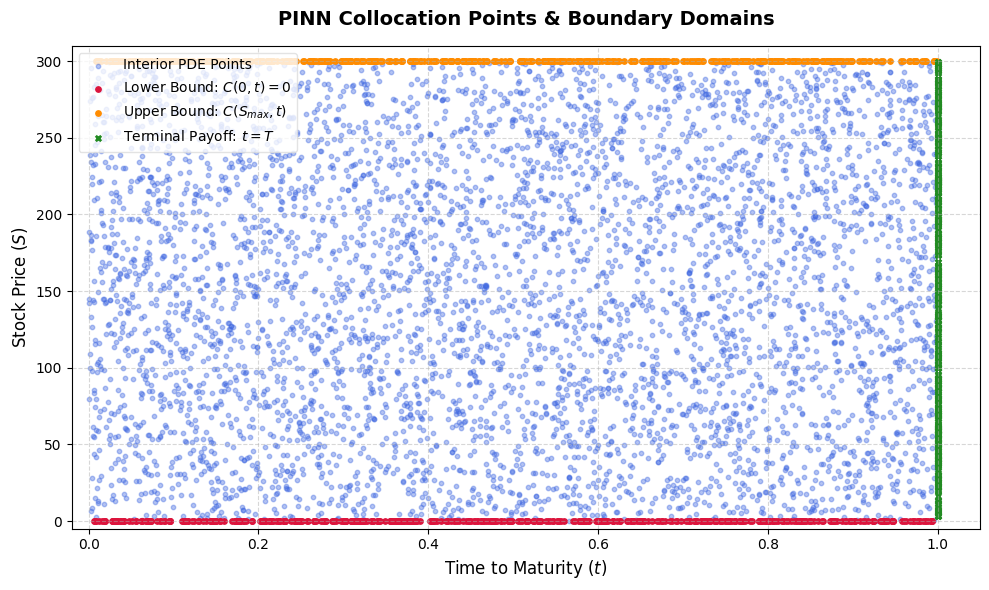

In [8]:
plot_collocation(S_max, T)

In [9]:
# Training PINN
def train_model_comp(data, model, optimizer, epochs):

    losses = []
    for epoch in range(epochs + 1):
        optimizer.zero_grad()
        
        # Compute the custom loss
        s, t = data
        loss = compute_pinn_loss(s, t, model)
        total_loss_tensor = sum(loss)
        total_loss = total_loss_tensor.item()
        if epoch % 500 == 0:
            print(
                f"Epoch {epoch:<5d} | "
                f"Total Loss: {total_loss:>12.6f} | "
                f"BC1 Loss: {loss[0].item():>12.6f} | "
                f"BC2 Loss: {loss[1].item():>12.6f} | "
                f"Terminal Loss: {loss[2].item():>12.6f} | "
                f"ODE Loss: {loss[3].item():>12.6f}"
            )

        losses.append(total_loss)

        total_loss_tensor.backward()
        optimizer.step()

    return losses

model = PINN_BS()
epochs = 3000
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
data = collocation_points(S_max, T, n_pde=2000, n_boundary=500)
training_loss = train_model_comp(data, model, optimizer, epochs)

c:\Users\goody\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0     | Total Loss: 50141.500000 | BC1 Loss:     0.007677 | BC2 Loss: 40985.671875 | Terminal Loss:  9155.822266 | ODE Loss:     0.000042
Epoch 500   | Total Loss: 32686.673828 | BC1 Loss:     0.264885 | BC2 Loss: 27603.341797 | Terminal Loss:  5076.892090 | ODE Loss:     6.174210
Epoch 1000  | Total Loss: 21784.408203 | BC1 Loss:     0.016307 | BC2 Loss: 18909.294922 | Terminal Loss:  2869.536133 | ODE Loss:     5.560499
Epoch 1500  | Total Loss: 14042.233398 | BC1 Loss:     0.001717 | BC2 Loss: 12511.298828 | Terminal Loss:  1524.376587 | ODE Loss:     6.556131
Epoch 2000  | Total Loss:  8656.171875 | BC1 Loss:     0.001251 | BC2 Loss:  7898.244141 | Terminal Loss:   744.396423 | ODE Loss:    13.530731
Epoch 2500  | Total Loss:  5022.703613 | BC1 Loss:     0.001450 | BC2 Loss:  4685.190918 | Terminal Loss:   319.835205 | ODE Loss:    17.676352
Epoch 3000  | Total Loss:  2730.151855 | BC1 Loss:     0.000674 | BC2 Loss:  2572.864014 | Terminal Loss:   122.963120 | ODE Loss:    34

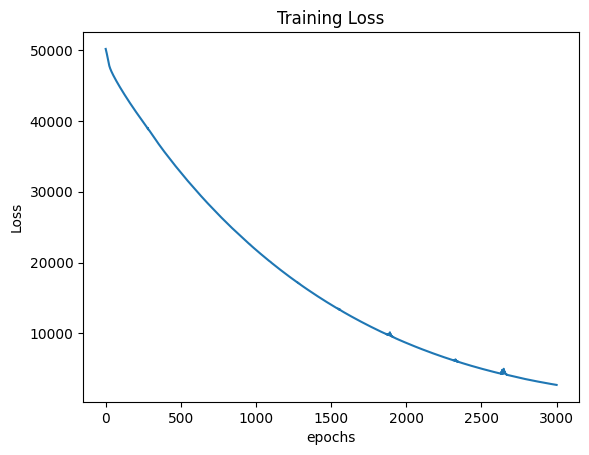

In [10]:
plt.plot(np.arange(0, epochs + 1), training_loss)
plt.ylabel("Loss")
plt.xlabel("epochs")
plt.title("Training Loss")
plt.show()

Total Loss: 240.2612971212926


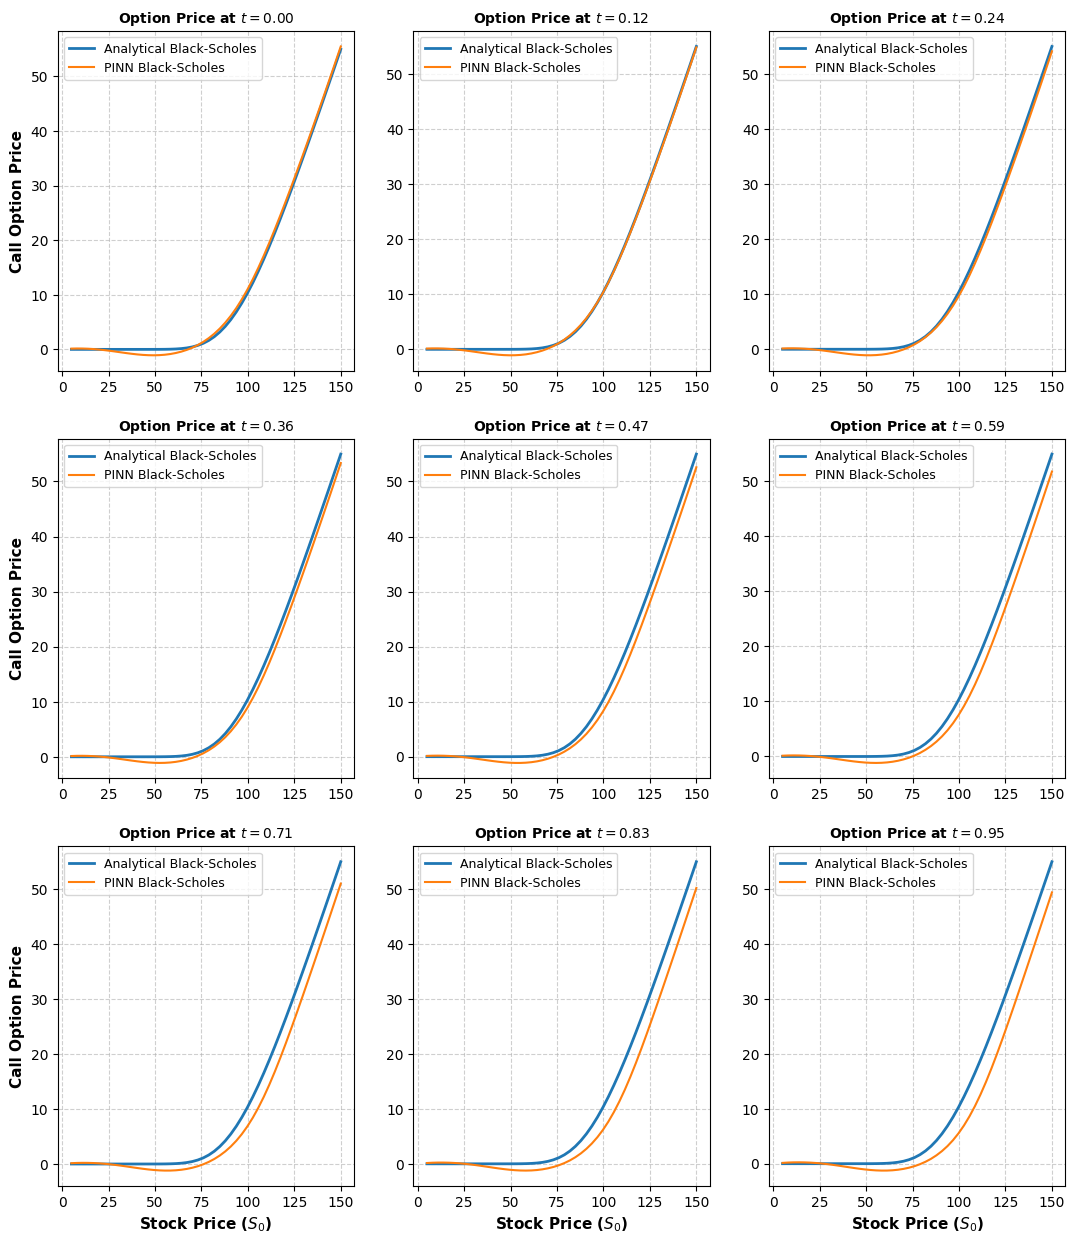

In [11]:
print(f"Total Loss: {compare_methods(r, sigma, K, T, model)}")

## Optimization

Standard PINN training often exhibits large initial loss and slow convergence, leading to inaccurate Black-Scholes estimations. This is likely caused by an ill-conditioned loss landscape.

### Key Observations

* **Optimizer Performance:** First-order methods like SGD and AdaGrad struggle to converge on PINN loss surfaces.
* **Recommended Approaches:** Literature suggests using **Adam**, **L-BFGS**, or a hybrid **Adam + L-BFGS** strategy.
* **Curvature Analysis:** To understand training dynamics and stiffness, loss landscape can be analyze by computing the spectral density (eigenvalues) of the Hessian matrix at different parts of training.

---

### References
* [PyHessian for Neural Network Analysis (Yao et al., 2019)](https://arxiv.org/abs/1912.07145)
* [Challenges in Training PINNs: A Loss Landscape Perspective](https://arxiv.org/abs/2402.01868)

In [12]:
from pyhessian import hessian
from pyhessian import get_esd_plot

In [13]:
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility
K = 100        # Strike price
T = 1          # Time to maturity (1 year)
S_max = 3 * K  # Upper Boundary for S -> inf

data = collocation_points(S_max, T, n_pde=5000, n_boundary=500)
new_model = PINN_BS()

In [14]:
def check_esd(model, compute_pinn_loss, data, optimizer, device='cuda'):

    esd_plot = []
    for epoch in range(epochs + 1):
        optimizer.zero_grad()
        
        # Compute the custom loss
        s, t = data
        loss = compute_pinn_loss(s, t, model)
        total_loss_tensor = sum(loss)
        total_loss = total_loss_tensor.item()
        if epoch % 500 == 0:
            print(
                f"Epoch {epoch:<5d} | "
                f"Total Loss: {total_loss:>12.6f} | "
                f"BC1 Loss: {loss[0].item():>12.6f} | "
                f"BC2 Loss: {loss[1].item():>12.6f} | "
                f"Terminal Loss: {loss[2].item():>12.6f} | "
                f"ODE Loss: {loss[3].item():>12.6f}"
            )

        total_loss_tensor.backward()
        optimizer.step()

        if epoch % 1500 == 0:
            h = hessian(model, compute_pinn_loss, data, device)
            eigen_list_full, weight_list_full = h.density()
            esd_plot.append([eigen_list_full, weight_list_full, epoch])
        
    return esd_plot
    

Epoch 0     | Total Loss: 50213.062500 | BC1 Loss:     0.028285 | BC2 Loss: 40947.976562 | Terminal Loss:  9265.060547 | ODE Loss:     0.000113
Epoch 500   | Total Loss: 32848.847656 | BC1 Loss:     0.083505 | BC2 Loss: 27713.144531 | Terminal Loss:  5127.930664 | ODE Loss:     7.688056
Epoch 1000  | Total Loss: 21915.044922 | BC1 Loss:     0.196843 | BC2 Loss: 19013.125000 | Terminal Loss:  2895.951172 | ODE Loss:     5.771404
Epoch 1500  | Total Loss: 14183.571289 | BC1 Loss:     0.003111 | BC2 Loss: 12613.069336 | Terminal Loss:  1564.019287 | ODE Loss:     6.479015
Epoch 2000  | Total Loss:  8778.531250 | BC1 Loss:     0.068847 | BC2 Loss:  7979.296387 | Terminal Loss:   789.419678 | ODE Loss:     9.745886
Epoch 2500  | Total Loss:  5128.701172 | BC1 Loss:     0.000167 | BC2 Loss:  4745.272461 | Terminal Loss:   362.918976 | ODE Loss:    20.509724
Epoch 3000  | Total Loss:  2789.442871 | BC1 Loss:     0.000762 | BC2 Loss:  2605.179199 | Terminal Loss:   152.209457 | ODE Loss:    32

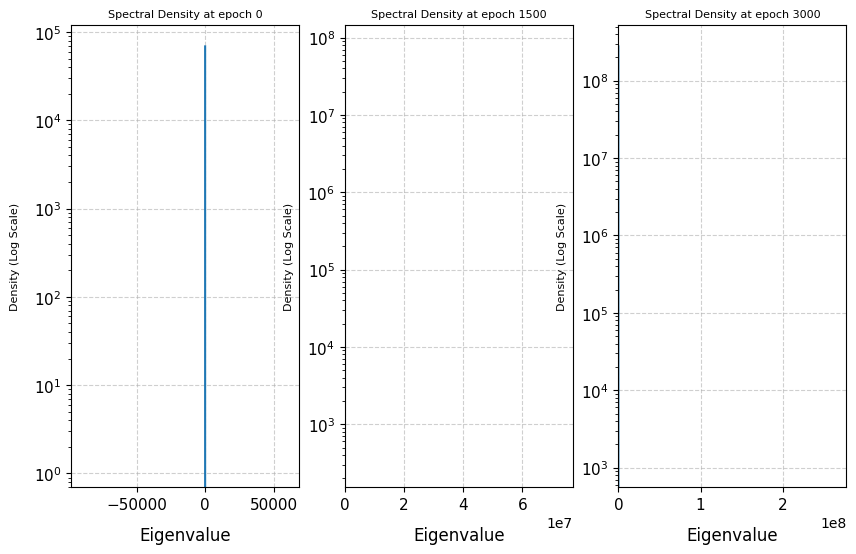

In [15]:
epochs = 3000
optimizer = torch.optim.Adam(new_model.parameters(), lr=0.001)
esd_plot = check_esd(new_model, compute_pinn_loss, data, optimizer, device='cuda')
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(10, 6))
ax = axs.flatten()
for i in range(3):
    eigenvalues = esd_plot[i][0]
    weights = esd_plot[i][1]
    epoch = esd_plot[i][2]
    grids, density = get_esd_plot(eigenvalues, weights)
    ax[i].semilogy(grids, density + 1.0e-7)
    ax[i].set_title(f'Spectral Density at epoch {epoch}', fontsize=8)
    ax[i].set_ylabel('Density (Log Scale)', fontsize=8, labelpad=10)
    ax[i].set_xlabel('Eigenvalue', fontsize=12, labelpad=10)
    ax[i].tick_params(axis='both', which='major', labelsize=11)
    ax[i].set_xlim([np.min(eigenvalues) - 1, np.max(eigenvalues) + 1])
    ax[i].grid(True, linestyle='--', alpha=0.6)

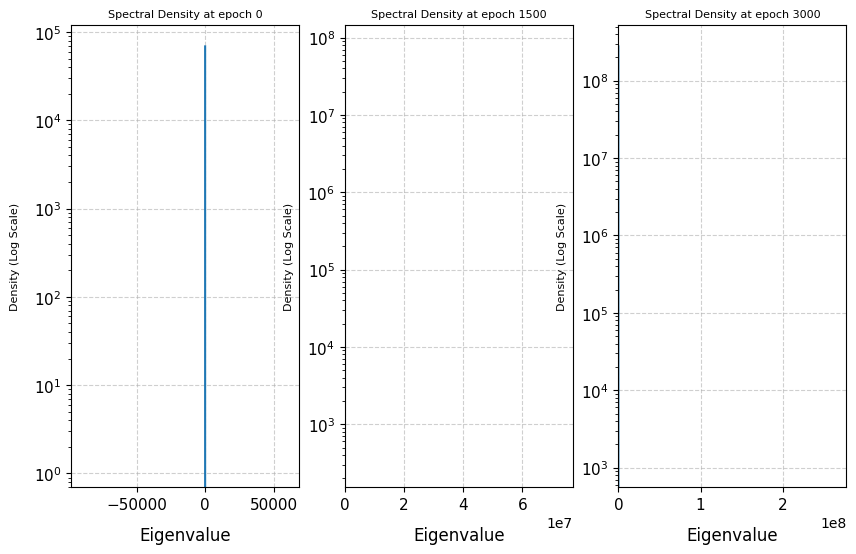

In [16]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(10, 6))
ax = axs.flatten()
for i in range(3):
    eigenvalues = esd_plot[i][0]
    weights = esd_plot[i][1]
    epoch = esd_plot[i][2]
    grids, density = get_esd_plot(eigenvalues, weights)
    ax[i].semilogy(grids, density + 1.0e-7)
    ax[i].set_title(f'Spectral Density at epoch {epoch}', fontsize=8)
    ax[i].set_ylabel('Density (Log Scale)', fontsize=8, labelpad=10)
    ax[i].set_xlabel('Eigenvalue', fontsize=12, labelpad=10)
    ax[i].tick_params(axis='both', which='major', labelsize=11)
    ax[i].set_xlim([np.min(eigenvalues) - 1, np.max(eigenvalues) + 1])
    ax[i].grid(True, linestyle='--', alpha=0.6)

In [17]:
from optim import optim_tune

In [18]:
num_models = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models = [PINN_BS().to(device) for _ in range(num_models)]
data = collocation_points(S_max, T, n_pde=5000, n_boundary=500)

configs = {
    "Adam": {
        "model": models[0],
        "optimizer": torch.optim.Adam(models[0].parameters(), lr=0.001),
        "epochs": 3000
    },
    "LBFGS_wolfe": {
        "model": models[1],
        "optimizer": torch.optim.LBFGS(models[1].parameters(), lr=1.0, max_iter=20, line_search_fn="strong_wolfe"),
        "epochs": 150
    },
    "AdaGrad": {
        "model": models[2],
        "optimizer": torch.optim.Adagrad(models[2].parameters(), lr=0.001),
        "epochs": 3000
    },
    "Adam+LBFGS" : {
        "model": models[3],
        "optimizer_LBFGS": torch.optim.LBFGS(models[3].parameters(), lr=1.0, max_iter=20, line_search_fn="strong_wolfe"),
        "optimizer_Adam" : torch.optim.Adam(models[3].parameters(), lr=0.001),
        "epochs_Adam": 1000,
        "epochs_LBFGS" : 100,
    }
}

In [19]:
results = optim_tune(configs, data)

Training with Adam...
Epoch 0 | Total Loss: 50001.394531
Epoch 500 | Total Loss: 32477.673828
Epoch 1000 | Total Loss: 21632.548828
Epoch 1500 | Total Loss: 13961.212891
Epoch 2000 | Total Loss: 8623.965820
Epoch 2500 | Total Loss: 5025.520020
Training with LBFGS...
Epoch 0 | Total Loss: 13628.490883
Training with Adagrad...
Epoch 0 | Total Loss: 50017.199219
Epoch 500 | Total Loss: 46388.644531
Epoch 1000 | Total Loss: 45687.566406
Epoch 1500 | Total Loss: 45188.414062
Epoch 2000 | Total Loss: 44781.710938
Epoch 2500 | Total Loss: 44430.960938
Training with Adam...
Epoch 0 | Total Loss: 50047.695312
Epoch 500 | Total Loss: 32741.091797
Training with LBFGS...
Epoch 0 | Total Loss: 12312.690544


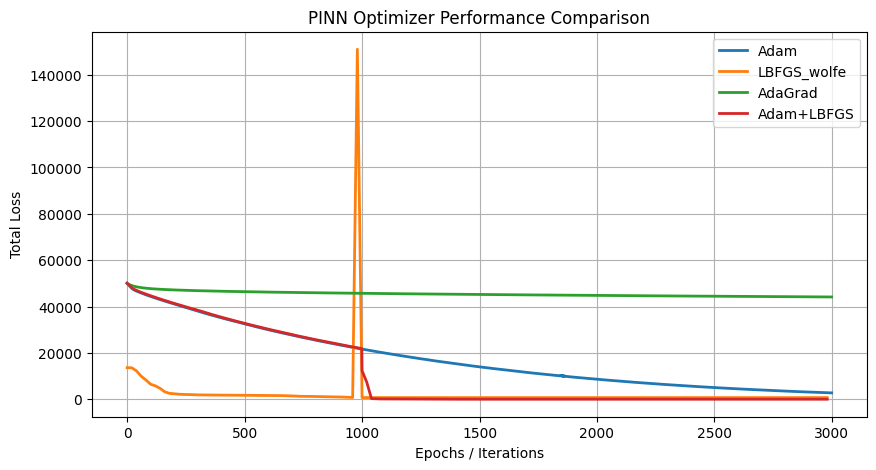

In [20]:
plt.figure(figsize=(10, 5))
for name, data in results.items():
    plt.plot(data["x"], data["y"], label=name, linewidth=2)
plt.xlabel('Epochs / Iterations')
plt.ylabel('Total Loss')
plt.title('PINN Optimizer Performance Comparison')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

In [21]:
for name, data in results.items():
    print(f'Loss ({name}): {data["y"][-1]}')

Loss (Adam): 2735.70556640625
Loss (LBFGS_wolfe): 704.3382320404053
Loss (AdaGrad): 44119.1875
Loss (Adam+LBFGS): 2.215707221534103
